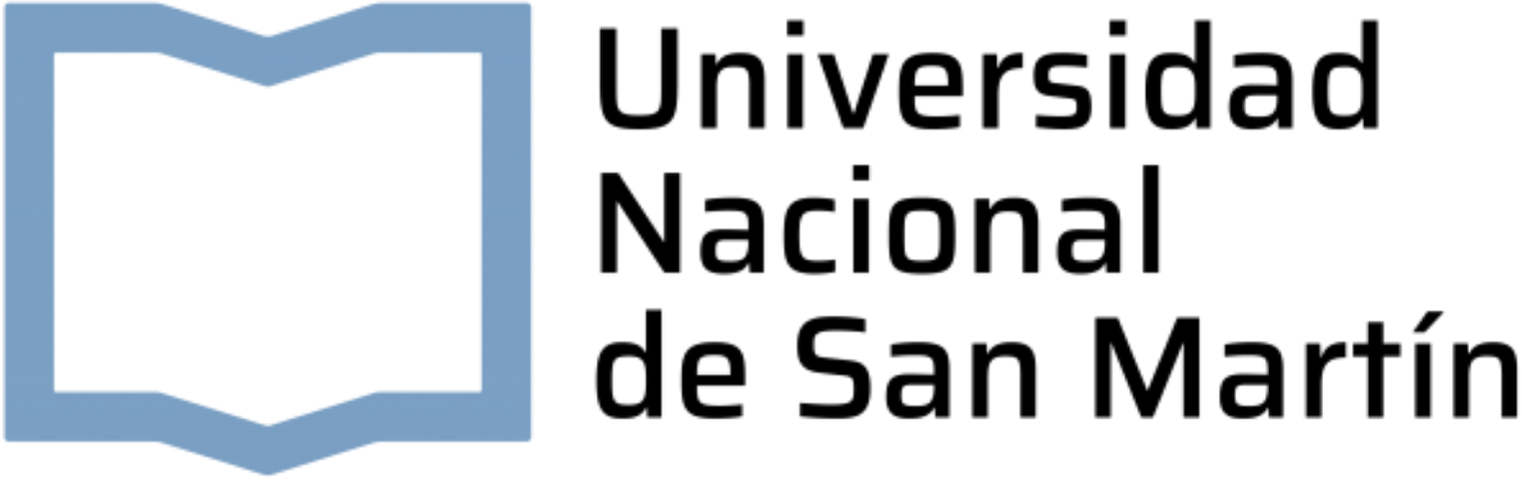

# TS2: Modelizando un ADC
# Cristóbal Contador

## Introducción

En esta práctica se tiene como objetivo armar y simular el funcionamiento de un conversor analógico-digital (ADC) utilizando Python. La idea principal es recrear el proceso completo que atraviesa una señal: partimos de una señal senoidal analógica pura, le agregamos ruido analógico y luego analizamos qué sucede al digitalizarla mediante el proceso de cuantización.

El foco del trabajo está puesto en estudiar cómo se modifica el comportamiento del sistema al variar dos parámetros principales:

* **Cantidad de bits ($B$):** nos da la resolución del ADC lo cual es el tamaño de los niveles de cuantización.
* **Factor de ruido ($k_n$):** nos da la relación entre el ruido analógico de la señal y el ruido del proceso de cuantización.

A lo largo de esta simulación se analizarán estos efectos mediante tres representaciones principales:

1. **Señal en dominio temporal**, para observar cómo el ruido y la cuantización afectan la forma de onda.
2. **Espectro en frecuencia**, obtenido mediante la FFT, para poder ver cómo se distribuye la energía de la señal y del ruido.
3. **Histograma del error de cuantización**, para estudiar experimentalmente su distribución y compararla con el comportamiento esperado según la teoría.


## a) Generar el siguiente resultado producto de la experimentación. $B$ = 4 bits, $k_n$=1

Empezamos por importar las librerias y hacer todos los calculos previos a graficar:

In [1]:
#%%
import numpy as np
import matplotlib.pyplot as plt

print ("import hechos")
plt.close('all')

fs = 1000
N = 1000

vmax = np.sqrt(2)
k = 1
df = fs/N

def mi_funcion_sen():
    nn = np.arange(N)/fs
    xx = (vmax * np.sin(2 * np.pi * k * df * nn))
    return (nn,xx)

nn, xx = mi_funcion_sen()

print("señal de seno lista")
kn = 1
B = 4
vf = 1
qq = 2 * vf / (2**B)
pq = (qq**2) / 12
pr = kn * pq  

psen = (vmax**2) / 2  
snr = 10 * np.log10(psen / pr)  

def generador_ruido(SNR, Psen):  
    Pr_calc = Psen / (10**(SNR/10))
    return np.random.normal(0, np.sqrt(Pr_calc), N)

ruido = generador_ruido(snr, psen)
print("señal de ruido lista")
suma = xx + ruido

suma_cuant = np.round(suma / qq) * qq
nq = suma_cuant - suma

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
phasesum = np.angle(fftsum)
ff = np.arange(N // 2) * df

modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)  
fftnq = np.fft.fft(nq) / N  
modulo_nq_db = 10 * np.log10(2 * (np.abs(fftnq[:N//2])) ** 2) 
piso_analogico_db = 10 * np.log10(2 * pr / N)  
piso_digital_db = 10 * np.log10(2 * pq / N)  

fftruido = np.fft.fft(ruido) / N  
modulo_ruido_db = 10 * np.log10(2 * (np.abs(fftruido[:N//2])) ** 2)  
fftsuma = np.fft.fft(suma) / N  
modulo_suma_db = 10 * np.log10(2 * (np.abs(fftsuma[:N//2])) ** 2)  
print("calculos hechos")

import hechos
señal de seno lista
señal de ruido lista
calculos hechos


Ahora graficaremos nuestra señal en el dominio del tiempo, nuestro grafico espectral y nuestro histograma del error de cuantización. Analizaremos cada una:

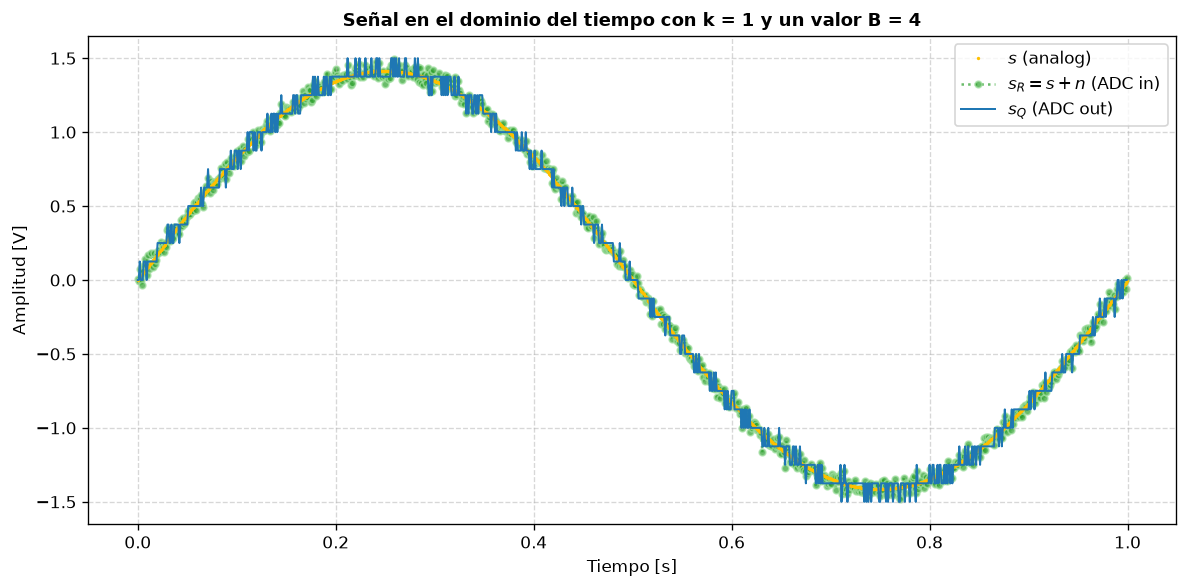

In [2]:
#%%
plt.figure(figsize=(10, 5), dpi=120)

plt.plot(nn, xx, label="$s$ (analog)", color="#FFC000", linestyle="", marker="o", markersize=1, zorder=2)

plt.plot(nn, suma, label="$s_R = s + n$ (ADC in)", color="#2ca02c", linestyle=":", marker="o", markersize=4, 
         markerfacecolor="#2ca02c", markeredgecolor="#a1dfa1", alpha=0.7, zorder=1)

plt.plot(nn, suma_cuant, label="$s_Q$ (ADC out)", color="#1f77b4", linestyle="-", linewidth=1.2, zorder=3)

plt.title(f"Señal en el dominio del tiempo con k = {kn} y un valor B = {B}", fontsize=11, fontweight='bold')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()


> **Figura 1. Señal en el dominio del tiempo.** Se observa la senoidal analógica de entrada ($s$), la señal ruidosa ($s_R$) y la señal cuantizada ($s_Q$).

En este grafico (Figura 1) podemos analizar cada una de las tres señales:
* La señal $s(analog)$ que es simplemente nuestra señal inicial senoidal pura sin ruido, sigue una forma de sinoidal con una frecuencia de 1Hz.
* La señal $s_R$ que es la señal sinoidial sumada al ruido, la cual sigue la forma de la sinoidial pero se separa de los valores de amplitud esperados debido al ruido que tiene ahora.
* La señal $s_Q$ que es la señal que tiene ya el ruido analógico + el ruido digital, se ve como una línea continua que va saltando de nivel debido a la cuantización del ADC de 4 bits. Al tener esta resolución, el conversor no puede representar infinitos valores por lo que redondea cada muestra de la entrada $s_R$ al nivel más cercano. Como calculamos que nuestro paso de cuantización ($qq$) es de $0.125\text{ V}$, la señal azul solo puede tomar valores que sean múltiplos de este paso, lo cual genera este efecto en el grafico.

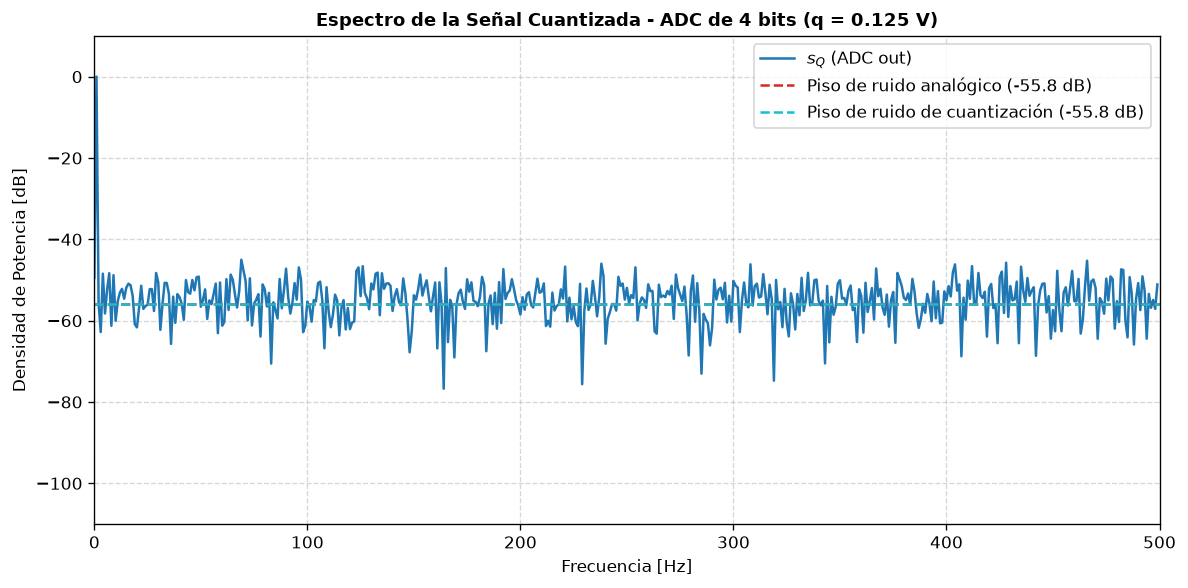

In [3]:
#%%
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1.5)

plt.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso de ruido analógico ({piso_analogico_db:.1f} dB)")
plt.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso de ruido de cuantización ({piso_digital_db:.1f} dB)")

plt.title(f"Espectro de la Señal Cuantizada - ADC de {B} bits (q = {qq} V)", fontsize=11, fontweight='bold')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlim(0, fs/2)
plt.ylim(-110, 10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()


> **Figura 2. Análisis espectral de la señal cuantizada.** Espectro de potencia de la señal de salida ($s_Q$) para un ADC de 4 bits. Las líneas punteadas representan los niveles teóricos de ruido analógico (rojo) y de cuantización (celeste), calculados para un factor de ruido $k_n = 1$.

En este gráfico (Figura 2) pasamos hacia el dominio de la frecuencia para analizar cómo se distribuye la potencia en el espectro:
* **La señal de salida $s_Q$ (curva azul):** Muestra un pico muy angosto en $1 { Hz}$ que llega exactamente a $0 { dB}$ lo que equivale a $1 { W}$ de potencia de la senoidal. Fuera de eso, se ve ruido que se extiende hasta los $500 { Hz}$, lo cual es la frecuencia de Nyquist $f_s/2$. Al ser completamente plano, lo cual confirma de forma práctica que el ruido se comporta como ruido blanco.
* **El piso de ruido analógico teórico (línea punteada roja):** Se ubica exactamente en $-55.8 { dB}$. Representa la potencia del analogico que viene antes de entrar al ADC, distribuida en todo el espectro.
* **El piso de ruido de cuantización teórico (línea punteada celeste):** Se ubica también en $-55.8 { dB}$. Representa el límite de resolución debido a los 4 bits del ADC, por lo que redondea las muestras. Como el factor de ruido es $k_n = 1$, ambos pisos coinciden.

Esto nos dice que estamos en el punto de equilibrio de diseño: subir los bits del ADC para bajar el piso celeste no mejoraría la calidad general, porqué el piso de ruido analógico que viene de afuera nos seguiría limitando de todos modos.

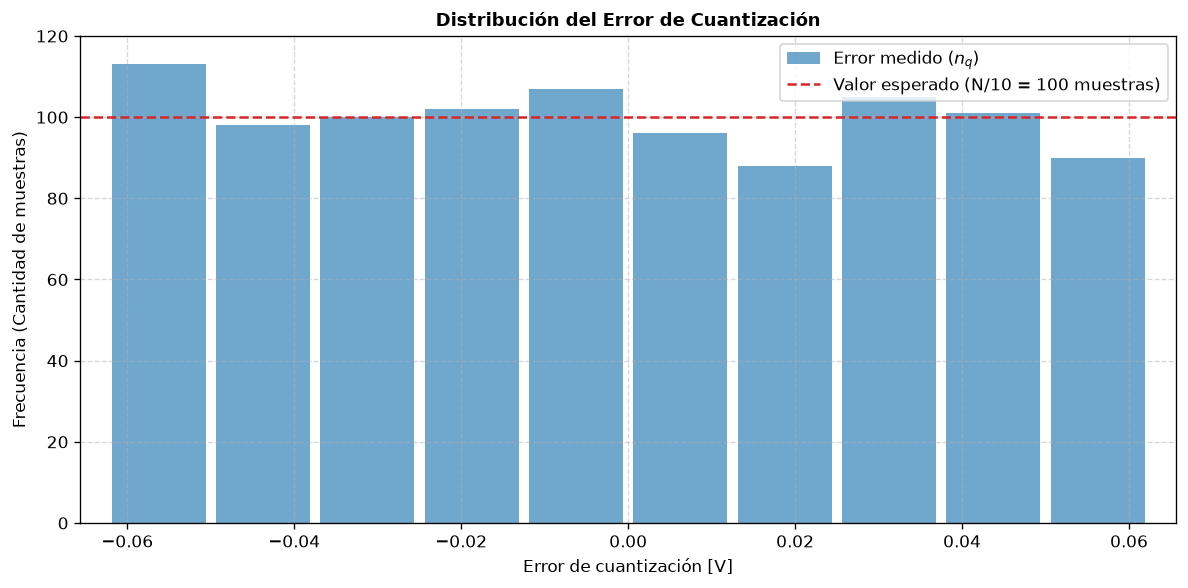

In [4]:
#%%
plt.figure(figsize=(10, 5), dpi=120)
bins = np.linspace(-qq/2, qq/2, 11)
plt.hist(nq, bins=bins, density=False, color="#3282b8", rwidth=0.9, alpha=0.7, label="Error medido ($n_q$)")

plt.axhline(N/10, color="#d62728", linestyle="--", linewidth=1.5, label=f"Valor esperado (N/10 = {N/10:.0f} muestras)")

plt.title("Distribución del Error de Cuantización", fontsize=11, fontweight='bold')
plt.xlabel("Error de cuantización [V]")
plt.ylabel("Frecuencia (Cantidad de muestras)")

plt.xlim(-qq/2 * 1.05, qq/2 * 1.05)
plt.ylim(0, 120)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()

> **Figura 3. Distribución del error de cuantización.** Histograma que representa cuántas muestras de error caen en cada intervalo para el ADC de 4 bits. La línea punteada roja marca la cantidad teorica de muestras esperadas por bin para una distribución uniforme.

En este gráfico (Figura 3) analizamos estadisticamente como se comporta el ruido que agregamos al cuantizar la señal:
* **El error medido $n_q$ (barras azules):** Representa la diferencia entre lo que entra al ADC ($s_R$) y lo que sale despues de cuantizar ($s_Q$). Se vee que el error esta acotado entre $-qq/2$ y $qq/2$ (es decir, entre -0.0625 V y 0.0625 V). Ninguna muestra supera este límite porqué el redondeo al nivel más cercano nunca puede ser mayor a la mitad de un escalón. Además, las alturas del error son bastante parecidas entre ellas, lo que confirma de forma práctica que el error se distribuye de forma uniforme.
* **El valor esperado teórico (línea punteada roja):** Se ubica exactamente en 100 muestras. Como tenemos 1000 muestras totales y dividimos el histograma en 10 intervalos, teóricamente deberían caer unas 100 muestras en cada uno si la distribución fuera perfectamente uniforme. En el gráfico vemos que las barras reales estan alrededor de la línea de 100 debido a la aleatoriedad de la simulación, pero siguen la tendencia esperada.

Esto nos demuestra que el error de cuantización se comporta tal como dice la teoría: tiene una distribución uniforme, está limitado de forma estricta por $\pm q/2$ y actúa como un ruido blanco.


## b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}. Discutir los resultados respecto a lo obtenido en a).

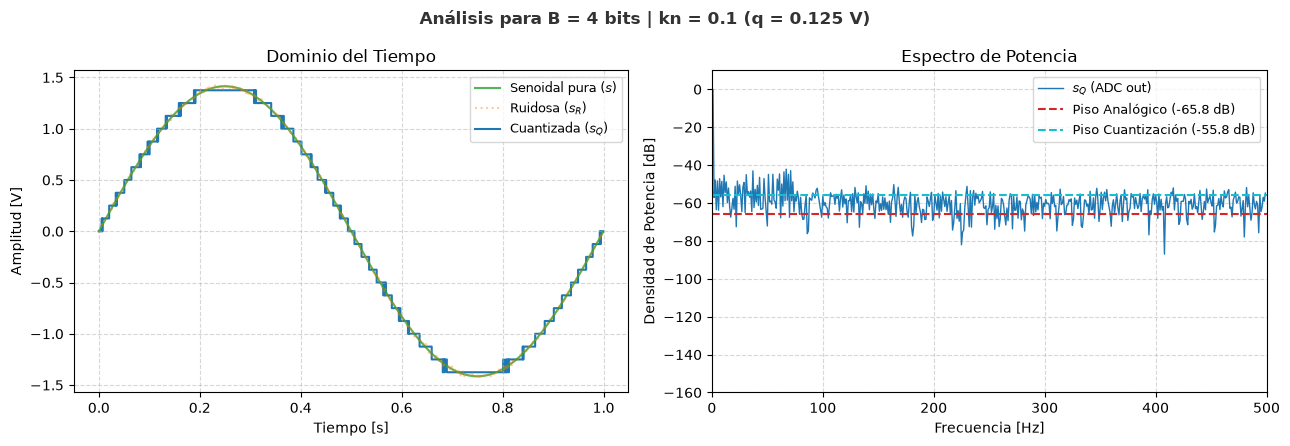

In [5]:
#%%
B = 4
kn = 1/10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 4. Señal cuantizada y espectro de potencia para B = 4 y $k_n = 1/10$.** Gráficos que muestran la señal
> pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 4 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=4$, $k_n=1/10$) (Figura 4)**

En este escenario de baja resolución y bajo ruido de entrada, el sistema está limitado por la cuantización, osea tenemos un cuello de botella digital. Como la potencia del ruido analógico es diez veces menor que la del ruido de cuantización $P_r = 1/10 \cdot P_q$, el piso de ruido digital $-55.8{ dB}$ se sitúa exactamente $10{ dB}$ por encima del analógico $-65.8{ dB}$. Con un paso de cuantización muy grande de $0.125{ V}$, el error de redondeo del ADC domina el espectro.

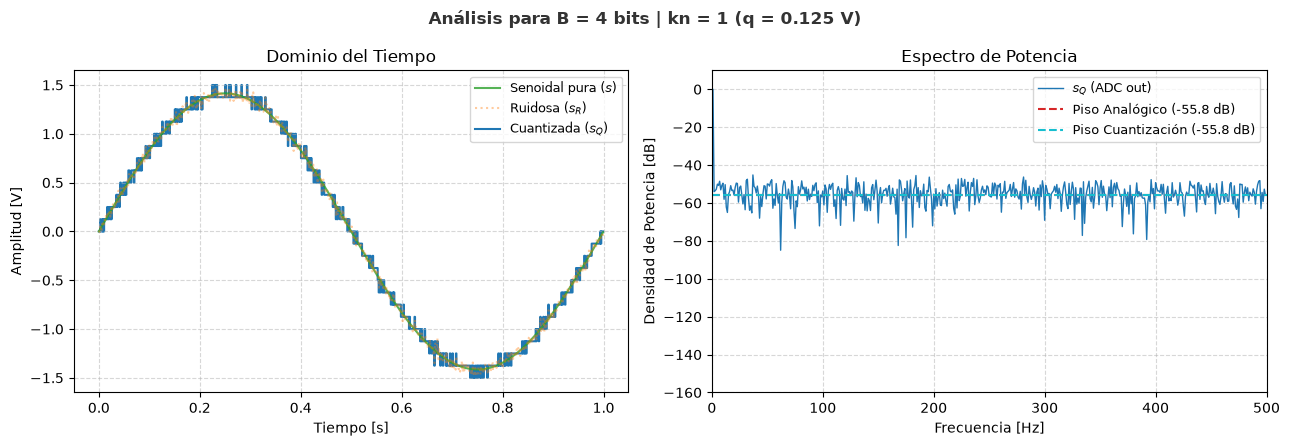

In [6]:
#%%
B = 4
kn = 1

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 5. Señal cuantizada y espectro de potencia para B = 4 y $k_n = 1$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 4 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=4$, $k_n=1$) (Figura 5)**

En este escenario de baja resolución y ruidos equilibrados, tenemos un equilibrio ideal entre ambas fuentes de ruido. Como la potencia del ruido analógico es igual a la del ruido de cuantización $P_r = 1 \cdot P_q$, el piso de ruido digital $-55.8{ dB}$ coincide exactamente con el analógico $-55.8{ dB}$. Con un paso de cuantización grande de $0.125{ V}$, el sistema no esta delimitado por solo un piso, sino que ambos lo delimitan exactamente igual.

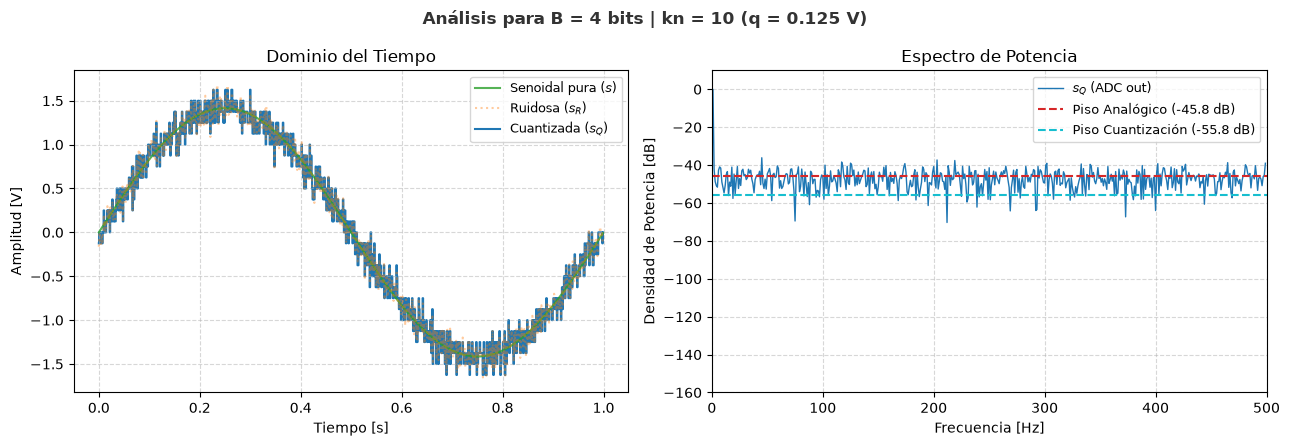

In [7]:
#%%
B = 4
kn = 10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 6. Señal cuantizada y espectro de potencia para B = 4 y $k_n = 10$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 4 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=4$, $k_n=10$) (Figura 6)**

En este escenario de baja resolución y alto ruido de entrada, el sistema está limitado por el ruido analógico,tenemos un cuello de botella analógico. Como la potencia del ruido analógico es diez veces mayor que la del ruido de cuantización $P_r = 10 \cdot P_q$, el piso de ruido analógico $-45.8 dB$ se sitúa exactamente $10 dB$ por encima del digital $-55.8 dB$. Con un paso de cuantización grande de $0.125 V$, el ruido analógico domina el espectro.

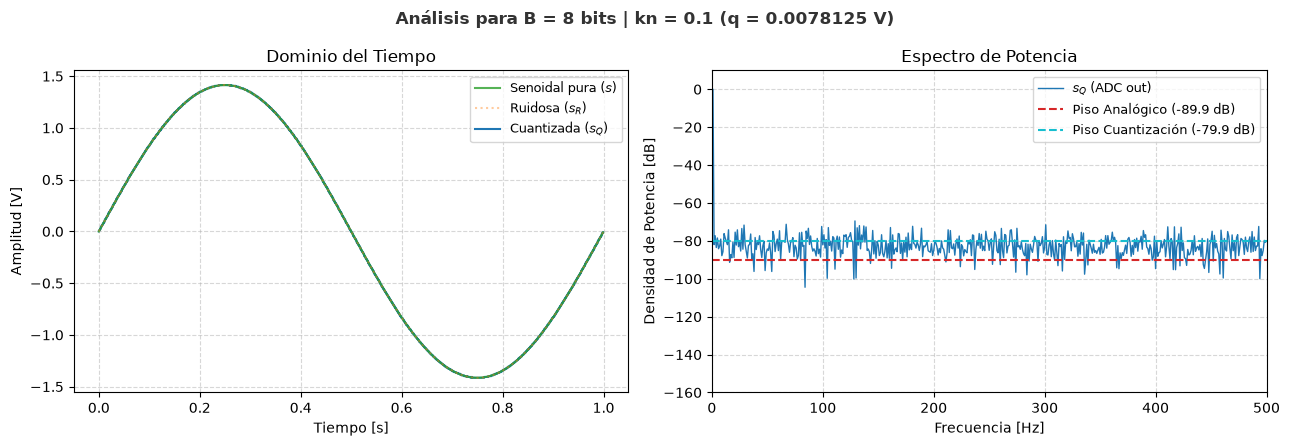

In [8]:
#%%
B = 8
kn = 1/10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 7. Señal cuantizada y espectro de potencia para B = 8 y $k_n = 1/10$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 8 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=8$, $k_n=1/10$) (Figura 7)**

En este escenario de resolución moderada y bajo ruido de entrada, el sistema está limitado por la cuantización, osea tenemos un cuello de botella digital. Como la potencia del ruido analógico es diez veces menor que la del ruido de cuantización $P_r = 1/10 \cdot P_q$, el piso de ruido digital $-79.9 dB$ se sitúa $10 dB$ por encima del analógico $-89.9 dB$. Con un paso de cuantización de apenas $0.0078125 V$ debido a los 256 niveles de resolución, la escalera de la señal no se puede ver en el dominio del tiempo sin hacerle zoom. A su vez, el ruido analógico es tan bajo que no llega a deformar la onda de manera visible, haciendo que la señal cuantizada se vea limpia y se superponga casi perfectamente con la senoidal pura, aunque el error de redondeo del ADC siga dominando el espectro de potencia.

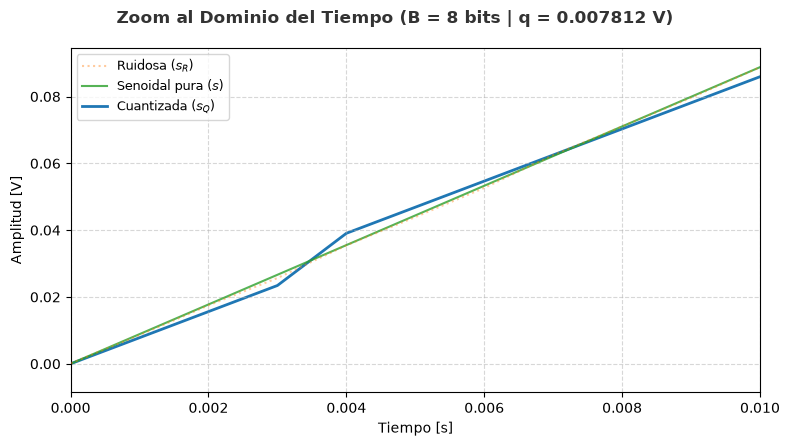

In [9]:
#%%
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
fig.suptitle(
    f"Zoom al Dominio del Tiempo (B = {B} bits | q = {qq:.6f} V)", 
    fontsize=12, 
    fontweight='bold', 
    color="#333333"
)

ax.plot(
    nn, 
    suma, 
    label="Ruidosa ($s_R$)", 
    color="#ff7f0e", 
    alpha=0.4, 
    linestyle=":", 
    zorder=3
)

ax.plot(
    nn, 
    xx, 
    label="Senoidal pura ($s$)", 
    color="#2ca02c", 
    alpha=0.8, 
    linewidth=1.5, 
    zorder=2
)

ax.plot(
    nn, 
    suma_cuant,  
    label="Cuantizada ($s_Q$)", 
    color="#1f77b4", 
    linewidth=2, 
    zorder=1
)

limite_muestras = 10
ax.set_xlim(nn[0], nn[limite_muestras])

datos_visibles = suma_cuant[:limite_muestras + 1]
max_val = np.max(datos_visibles)
min_val = np.min(datos_visibles)
margen = (max_val - min_val) * 0.1 if max_val != min_val else 0.1

ax.set_ylim(min_val - margen, max_val + margen)

ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud [V]")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 8. Señal cuantizada con zoom en sus primeras 10 muestra para B = 8 y $k_n = 1/10$.** Gráfico que muestran la señal
pura, ruidosa y cuantizada con un zoom para poder notar los diferencias.

**Analisis de la figura 8**

Al hacerle zoom a las primeras 10 muestras podemos apreciar como la señal cuantizada no sigue perfectamente a la señal senoidal pura, mostrandonos como antes no era que se volviera tan precisa sino que necesitabamos mas zoom para apreciarlo.

C:\Users\cristobal\AppData\Local\Temp\ipykernel_6252\2291083238.py:22: RuntimeWarning: divide by zero encountered in log10
  modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)


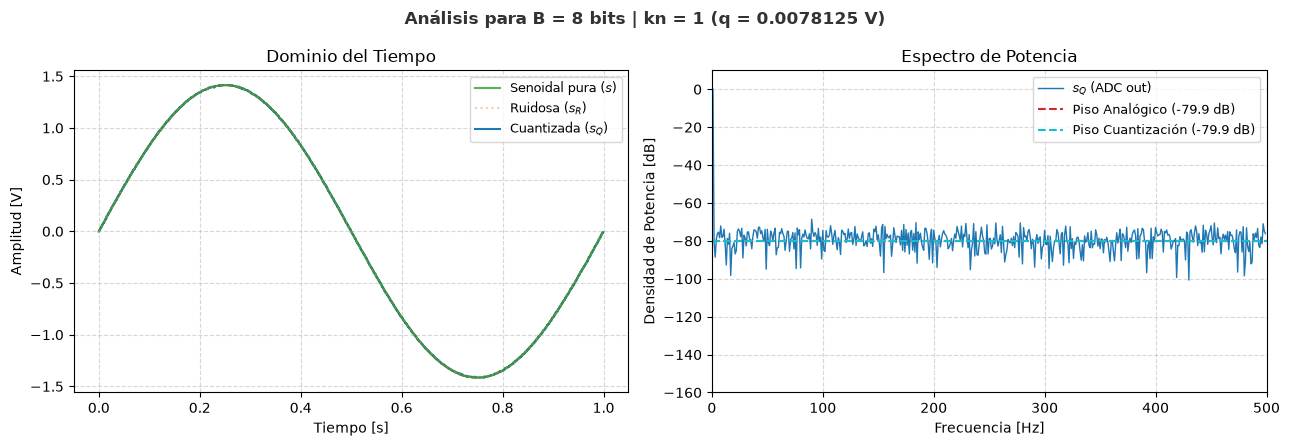

In [10]:
#%%
B = 8
kn = 1

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 9. Señal cuantizada y espectro de potencia para B = 8 y $k_n = 1$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 8 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=8$, $k_n=1$) (Figura 9)**

En este escenario de resolución moderada y ruidos equilibrados, tenemos un equilibrio entre ambas fuentes de ruido. Como la potencia del ruido analógico es igual a la del ruido de cuantización $P_r = 1 \cdot P_q$, el piso de ruido digital $-79.9 dB$ coincide exactamente con el analógico $-79.9 dB$. Con un paso de cuantización de $0.0078125 V$ debido a los 256 niveles de resolución, el sistema no esta delimitado por un solo piso, sino que ambos lo delimitan exactamente igual. En el dominio del tiempo, la señal sigue viéndose muy limpia, debido nuevamente a la falta de zoom.

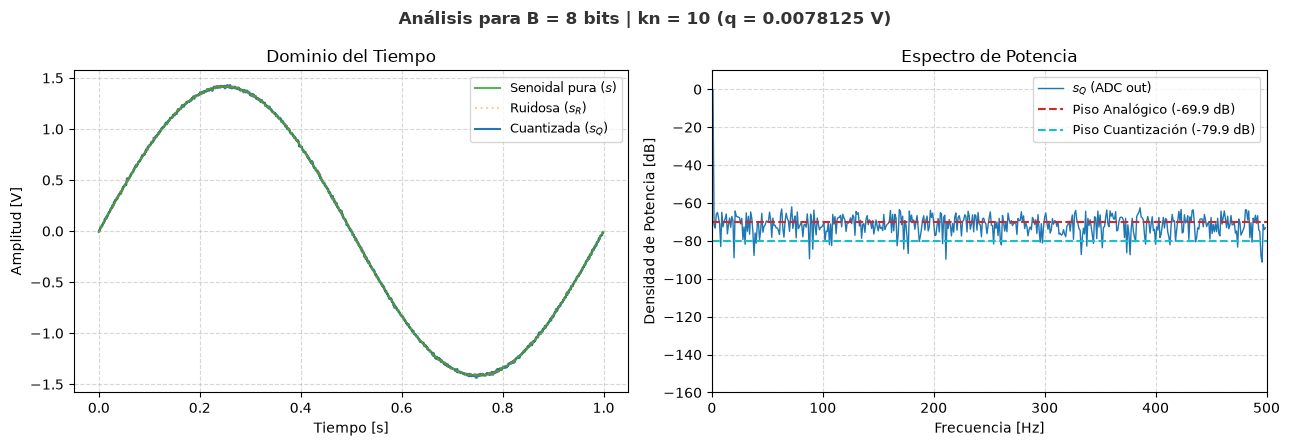

In [11]:
#%%
B = 8
kn = 10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 10. Señal cuantizada y espectro de potencia para B = 8 y $k_n = 10$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 8 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=8$, $k_n=10$) (Figura 10)**

En este escenario de resolución moderada y alto ruido de entrada, el sistema está delimitado por el ruido analógico, osea tenemos un cuello de botella analógico. Como la potencia del ruido analógico es diez veces mayor que la del ruido de cuantización $P_r = 10 \cdot P_q$, el piso de ruido analógico $-69.9 dB$ se sitúa exactamente $10 dB$ por encima del digital $-79.9 dB$. Con un paso de cuantización moderado de $0.007813 V$, el ruido analógico domina el espectro. En el dominio del tiempo, al ser el ruido analógico mucho mayor que el paso de cuantización, la señal ruidosa de entrada deforma la escalera azul de la señal cuantizada, haciendo que se vea mas ruidosa.

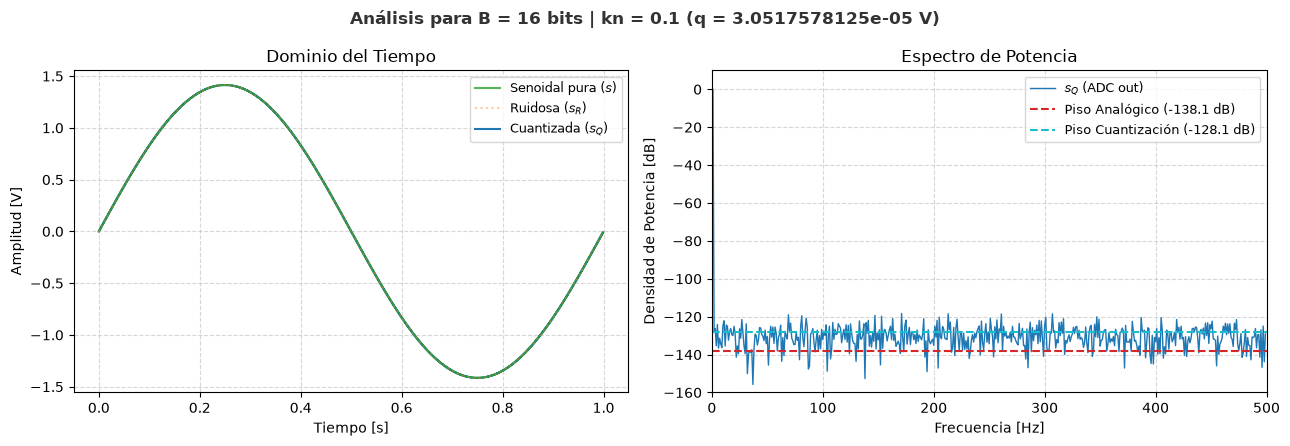

In [12]:
#%%
B = 16
kn = 1/10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 11. Señal cuantizada y espectro de potencia para B = 16 y $k_n = 1/10$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 16 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=16$, $k_n=1/10$) (Figura 11)**

En este escenario de alta resolución y bajo ruido de entrada, el sistema está limitado por la cuantización, osea tenemos un cuello de botella digital. Como la potencia del ruido analógico es diez veces menor que la del ruido de cuantización $P_r = 1/10 \cdot P_q$, el piso de ruido digital $-128.1 dB$ se sitúa $10 dB$ por encima del analógico $-138.1 dB$. Con un paso de cuantización de apenas $0.0000305 V$ debido a los 65536 niveles de resolución, la escalera de la señal no se puede ver en el dominio del tiempo sin hacerle zoom. Tambien el ruido analógico es tan bajo que no llega a deformar la onda de manera apreciable, haciendo que la señal cuantizada se vea limpia y se superponga casi perfectamente con la senoidal pura, aunque el error de redondeo del ADC siga dominando el espectro de potencia. 

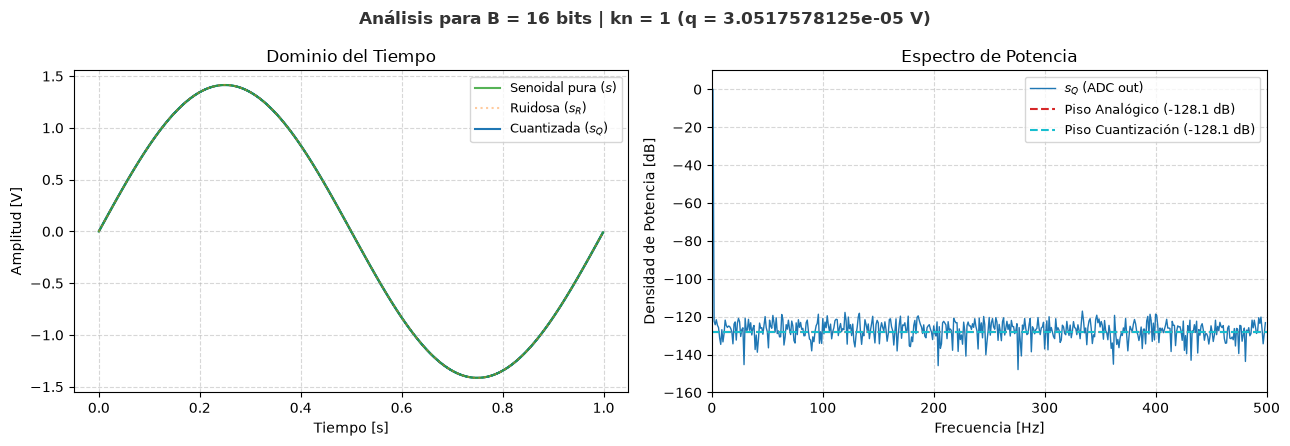

In [13]:
#%%
B = 16
kn = 1

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 12. Señal cuantizada y espectro de potencia para B = 16 y $k_n = 1$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 16 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=16$, $k_n=1$) (Figura 12)**

En este escenario de alta resolución y ruidos equilibrados, tenemos un equilibrio entre ambas fuentes de ruido. Como la potencia del ruido analógico es igual a la del ruido de cuantización $P_r = 1 \cdot P_q$, el piso de ruido digital $-128.1 dB$ coincide exactamente con el analógico $-128.1 dB$. Con un paso de cuantización de apenas $0.0000305 V$ debido a los 65536 niveles de resolución, el sistema no está delimitado por un solo piso, sino que ambos lo delimitan exactamente igual. En el dominio del tiempo, la señal sigue viéndose sumamente limpia, debido nuevamente a la falta de zoom.

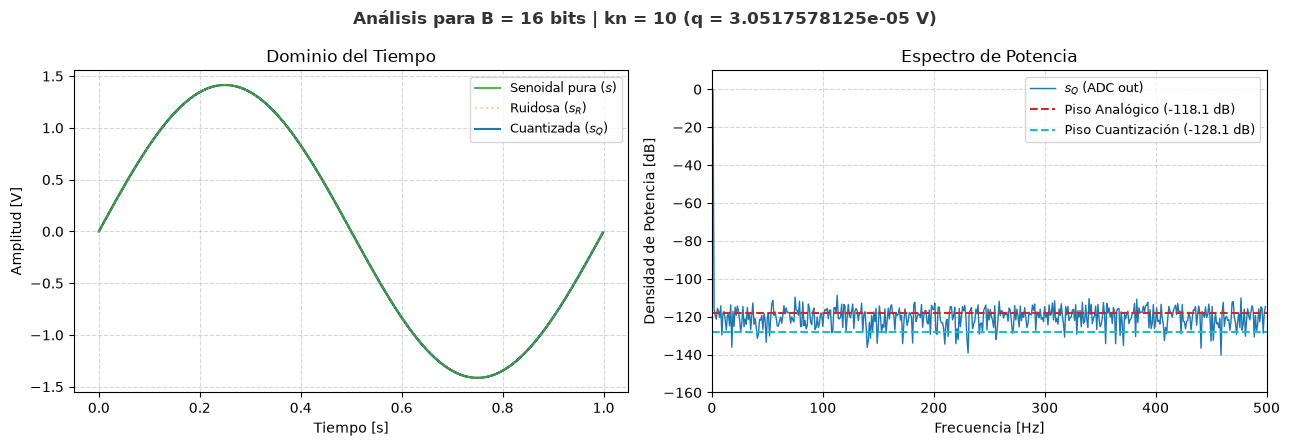

In [14]:
#%%
B = 16
kn = 10

vf = 1
qq = 2 * vf / (2**B)    
pq = (qq**2) / 12        
pr = kn * pq             

piso_analogico_db = 10 * np.log10(2 * pr / N)
piso_digital_db = 10 * np.log10(2 * pq / N)

snr_analog = 10 * np.log10(psen / pr)

ruido = generador_ruido(snr_analog, psen)
suma = xx + ruido
suma_cuant = np.round(suma / qq) * qq

fftsum = np.fft.fft(suma_cuant) / N
absolutosum = np.abs(fftsum)
ff = np.arange(N // 2) * df
modulo_cuant_db = 10 * np.log10(2 * (absolutosum[:N//2]) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
fig.suptitle(f"Análisis para B = {B} bits | kn = {kn} (q = {qq} V)", 
             fontsize=12, fontweight='bold', color="#333333")

ax1.plot(nn, xx, label="Senoidal pura ($s$)", color="#2ca02c", alpha=0.8, linewidth=1.5, zorder = 2)
ax1.plot(nn, suma, label="Ruidosa ($s_R$)", color="#ff7f0e", alpha=0.4, linestyle=":")
ax1.step(nn, suma_cuant, where="mid", label="Cuantizada ($s_Q$)", color="#1f77b4", linewidth=1.5, zorder = 1)
ax1.set_title("Dominio del Tiempo")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud [V]")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(ff, modulo_cuant_db, label="$s_Q$ (ADC out)", color="#1f77b4", linewidth=1)
ax2.axhline(piso_analogico_db, color="#d62728", linestyle="--", linewidth=1.5, 
            label=f"Piso Analógico ({piso_analogico_db:.1f} dB)")
ax2.axhline(piso_digital_db, color="#17becf", linestyle="--", linewidth=1.5, 
            label=f"Piso Cuantización ({piso_digital_db:.1f} dB)")
ax2.set_title("Espectro de Potencia")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Densidad de Potencia [dB]")
ax2.set_xlim(0, fs/2)
ax2.set_ylim(-160, 10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 13. Señal cuantizada y espectro de potencia para B = 16 y $k_n = 10$.** Gráficos que muestran la señal
pura, ruidosa y cuantizada (izquierda) y el espectro de potencia del ADC de 16 bits con sus pisos de ruido teóricos (derecha)

**Análisis de la configuración ($B=16$, $k_n=10$) (Figura 13)**

En este escenario de alta resolución y alto ruido de entrada, el sistema está delimitado por el ruido analógico, osea tenemos un cuello de botella analógico. Como la potencia del ruido analógico es diez veces mayor que la del ruido de cuantización $P_r = 10 \cdot P_q$, el piso de ruido analógico $-118.1 dB$ se sitúa exactamente $10 dB$ por encima del digital $-128.1 dB$. Con un paso de cuantización de apenas $0.0000305 V$ debido a los 65536 niveles de resolución, el ruido analógico domina el espectro.

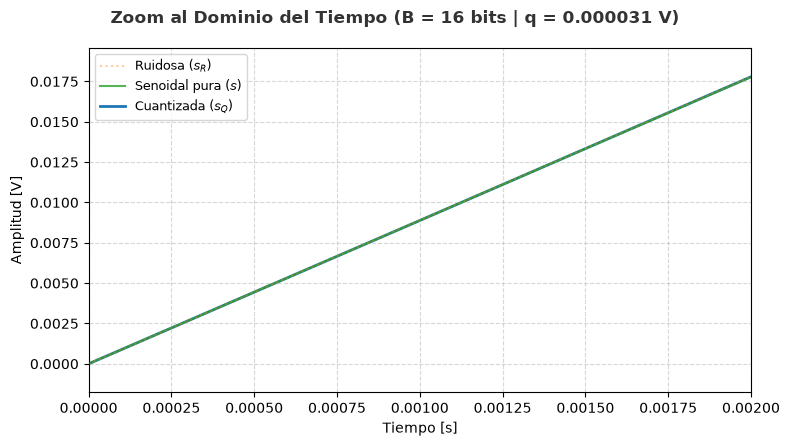

In [15]:
#%%
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
fig.suptitle(
    f"Zoom al Dominio del Tiempo (B = {B} bits | q = {qq:.6f} V)", 
    fontsize=12, 
    fontweight='bold', 
    color="#333333"
)

ax.plot(
    nn, 
    suma, 
    label="Ruidosa ($s_R$)", 
    color="#ff7f0e", 
    alpha=0.4, 
    linestyle=":", 
    zorder=3
)

ax.plot(
    nn, 
    xx, 
    label="Senoidal pura ($s$)", 
    color="#2ca02c", 
    alpha=0.8, 
    linewidth=1.5, 
    zorder=2
)

ax.plot(
    nn, 
    suma_cuant,  
    label="Cuantizada ($s_Q$)", 
    color="#1f77b4", 
    linewidth=2, 
    zorder=1
)

limite_muestras = 2
ax.set_xlim(nn[0], nn[limite_muestras])

datos_visibles = suma_cuant[:limite_muestras + 1]
max_val = np.max(datos_visibles)
min_val = np.min(datos_visibles)
margen = (max_val - min_val) * 0.1 if max_val != min_val else 0.1

ax.set_ylim(min_val - margen, max_val + margen)

ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud [V]")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

> **Figura 14. Señal cuantizada con zoom en sus primeras 2 muestras para B = 16 y $k_n =10$.** Gráfico que muestran la señal
pura, ruidosa y cuantizada con un zoom para poder notar las diferencias.

**Analisis de la figura 14**

Al hacerle zoom a las primeras 2 muestras podemos apreciar como la señal cuantizada aun no esta visiblemente separada de la senoidal pura, esto es debido a nuestra resolución la cual es tan grande que nisiquiera con dos muestras se puede apreciar la diferencia.

## Bonus
**Calcular el SNR de la señal cuantizada para cada caso y armar una tabla comparativa.**

In [16]:
#%%
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Usamos tus parámetros y tu función original de partida
fs = 1000
N = 1000
vmax = np.sqrt(2)
k = 1
df = fs/N

def mi_funcion_sen():
    nn = np.arange(N)/fs
    xx = (vmax * np.sin(2 * np.pi * k * df * nn))
    return (nn,xx)

nn, xx = mi_funcion_sen()
psen = (vmax**2) / 2  # Potencia de tu senoidal pura (1 W)
vf = 1

combinaciones = [
    (4, 0.1), (4, 1.0), (4, 10.0),
    (8, 0.1), (8, 1.0), (8, 10.0),
    (16, 0.1), (16, 1.0), (16, 10.0),
    (20, 0.1), (21, 0.1)
]

resultados = []

for B, kn in combinaciones:

    qq = 2 * vf / (2**B)
    pq = (qq**2) / 12
    pr = kn * pq  
    
   
    p_ruido_total_teorico = pq + pr
    snr_teorico = 10 * np.log10(psen / p_ruido_total_teorico)
    

    if pr > 0:
        ruido = np.random.normal(0, np.sqrt(pr), N)
    else:
        ruido = np.zeros(N)
        
    suma = xx + ruido  
    
    suma_cuant = np.round(suma / qq) * qq
    
    error = suma_cuant - xx
    
    p_ruido_real = np.mean(error**2)
    snr_empirico = 10 * np.log10(psen / p_ruido_real)
    
    resultados.append({
        "B": B,
        "kn": kn,
        "SNR Teórico [dB]": round(snr_teorico, 2),
        "SNR Experimental [dB]": round(snr_empirico, 2)
    })

df_snr = pd.DataFrame(resultados)
display(df_snr)

,B,kn,SNR Teórico [dB],SNR Experimental [dB]
0,4,0.1,28.44,28.73
1,4,1.0,25.84,26.00
2,4,10.0,18.44,18.33
3,8,0.1,52.52,53.02
4,8,1.0,49.93,50.23
5,8,10.0,42.52,42.72
6,16,0.1,100.69,100.69
7,16,1.0,98.09,98.22
8,16,10.0,90.69,90.92
9,20,0.1,124.77,125.05


> **Tabla 1: SNR teorico vs SNR experimental**
Se presenta una tabla con todas las combinaciones de B y kn que usamos en la experimentacion.

**Analisis Tabla 1**

El analisis de esta tabla nos permite extraer las siguientes conclusiones:
* **SNR cambios en funcion de kn** El SNR decrece al crecer la kn, esto se debe a que como en nuestro codigo definimos que $P_r = k_n \cdot P_q$ y que $P_s$ es fijo de **1W** y sabemos que la formula de SNR es $$SNR = \frac{\text{Señal}}{\text{Ruido}} = \frac{P_s}{P_{\text{ruido\_total}}}$$ Podemos analizar mediante la formula $$P_{\text{ruido\_total}} = P_q + k_n \cdot P_q = \mathbf{(1 + k_n) \cdot P_q}$$ que al haber un aumento en la kn hay un aumento directo en el $P_{\text{ruido\_total}}$ haciendo que la division del SNR resulte mas chica.
* **SNR en función de los bits ($B$):** El SNR aumenta mucho al incrementar los bits de resolución $B$. Esto se debe a que el paso de cuantización depende de la resolución mediante $q = \frac{2 \cdot V_f}{2^B}$, lo que hace que la potencia de ruido digital sea: $$P_q = \frac{q^2}{12} = \frac{V_f^2}{3 \cdot 2^{2B}}$$ Al aumentar $B$, el término exponencial $2^{2B}$ en el denominador crece de forma muy rapida, haciendo que $P_q$ se vuelva muy chico, lo cual afecta directamente a nuestra cuenta de SNR. Como el numerador $P_s$ se mantiene fijo en 1W, dividir por un ruido muy chico hace que el cociente del SNR crezca.
* Al agregar al final del todo dos casos con B = 20 y B = 21 pero el mismo kn pudimos ver como crece el SNR teorico por +6.02dB y el experimental por +5.73dB, reafirmando la teoria de Holton que nos dice que $$\mathbf{SNR \approx 6.02N + 1.76 \quad [dB]}$$ Por lo cual al el 1.76 sumar ambos terminos con distinta B podiamos esperar teoricamente que la diferencia de SNR fuese de 6.02, en el caso del SNR experimental no da exactamente eso debido simplemente a la aleatoridad del ruido generado.

## Conclusión
Este trabajo práctico simulamos el comportamiento real de un ADC ($f_s = 1000\text{ Hz}$ y rango de $\pm 1\text{ V}$), entendimos cómo interactúan el ruido analógico que llega a la entrada y el ruido digital de cuantización que es con el que se ve inducido adentro del ADC.
* **El impacto del ruido de entrada ($k_n$):** Comprobamos que el sistema siempre está limitado por el ruido mas fuerte. Si el ruido analógico que viene con la señal es muy alto ($k_n = 10$), se genera un cuello de botella analógico. En este caso, tener un ADC de muchísimos bits no sirve de nada porque el ruido de entrada tapa todo y baja el SNR. En cambio, si el ruido de entrada es bajo ($k_n = 0.1$), el limitante es la resolución del propio conversor.
* **La visualización del error:** En resoluciones altas como 8 o 16 bits, la señal original y la cuantizada son visualmente iguales en los gráficos. Esto nos enseñó que la única forma de analizar la pérdida de resolución real es aislar y hacer zoom para poder apreciar esas pequeñas deformaciones.
* **Validación de Holton:** Con la tabla comparativa que armamos en Python pudimos comparar que la teoría y la simulación son muy parecidas. Además, al agregar los casos de 20 y 21 bits, comprobamos experimentalmente la teoria que nos brinda Holton, cada bit físico que agregamos disminuye el paso de cuantización y nos da casi exactamente $6\text{ dB}$ extras de SNR ($5.92\text{ dB}$ en la simulación debido a la aleatoriedad del ruido).